# **Project 4 | Accuracy and Beyond**

# by Sandra Dela Cruz

# Data Preparation, Exploration, and Preprocessing

For this project, we use the Book-Crossing dataset from Kaggle, which contains book rating information including variables such as User-ID, ISBN, Rating, Title, and Author. The dataset is first explored and cleaned by handling missing values and removing unnecessary data. The processed dataset is then divided into training and testing sets for model evaluation.

This project investigates two matrix factorization-based collaborative filtering approaches: Singular Value Decomposition (SVD) optimized using Stochastic Gradient Descent (SGD) and Alternating Least Squares (ALS). Both models learn latent representations of users and books to generate personalized recommendations. Their performance is evaluated using both rating prediction metrics, including RMSE and MAE, and top-K recommendation metrics, including Precision@10 and Recall@10.

After establishing baseline performance, a novelty-aware recommendation strategy is introduced by adjusting the ranking score to reduce the influence of highly popular books. The goal of this modification is to improve recommendation novelty by encouraging the discovery of less frequently interacted items. In addition to measuring changes in Novelty@10, diversity metrics based on recommended authors are evaluated to investigate whether increasing novelty also leads to more diverse recommendation lists.

The results are used to analyze the trade-off between recommendation accuracy and user experience objectives, comparing how SVD-SGD and ALS respond to the novelty-aware modification.


In [1]:
# import libraries
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from collections import defaultdict
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix

In [2]:
# import dataset from GitHub
# original data source: https://www.kaggle.com/datasets/somnambwl/bookcrossing-dataset/code
!git clone https://github.com/lalaexplore/DATA-612.git

ratings = pd.read_csv('DATA-612/project 4/Ratings.csv', sep=";", encoding="latin-1")
books = pd.read_csv('DATA-612/project 4/Books.csv', sep=";", encoding="latin-1")

full_df = pd.merge(ratings, books, on='ISBN', how='left')

full_df.info()
full_df.head()

fatal: destination path 'DATA-612' already exists and is not an empty directory.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149792 entries, 0 to 1149791
Data columns (total 7 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   User-ID    1149792 non-null  int64  
 1   ISBN       1149792 non-null  object 
 2   Rating     1149792 non-null  int64  
 3   Title      1031187 non-null  object 
 4   Author     1031185 non-null  object 
 5   Year       1031187 non-null  float64
 6   Publisher  1031185 non-null  object 
dtypes: float64(1), int64(2), object(4)
memory usage: 61.4+ MB


,User-ID,ISBN,Rating,Title,Author,Year,Publisher
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002.0,Ballantine Books
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001.0,Heinle
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996.0,Warner Books
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999.0,Cambridge University Press
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001.0,Cambridge University Press


In [3]:
# Let's explore on 'Year', to decide to keep it or not
full_df['Year'] = full_df['Year'].fillna(0).astype(int)
full_df['Year'].describe()
full_df[full_df['Year'] < 1800]['Year'].value_counts().head() # check invalid year
full_df[full_df['Year'] > 2026]['Year'].value_counts().head()
# we decide to drop year as it contains a lot of missing values and not relevant for our analysis now

Year
2030    32
2038     8
2050     7
2037     1
Name: count, dtype: int64

In [4]:
# Let's explore ratings
full_df['Rating'].value_counts().sort_index() # Result: 0 = 716117

Rating
0     716117
1       1770
2       2759
3       5996
4       8904
5      50974
6      36925
7      76458
8     103737
9      67542
10     78610
Name: count, dtype: int64

In [5]:
# Since there are a lot of zero ratings , so let's remove it
# It's most likely that a user did not interact with the book or no ratings were left
# If we include this, it might unfairly penalize an author's overall rating
full_df = full_df[full_df['Rating']>0]
full_df['Rating'].value_counts().sort_index() 

Rating
1       1770
2       2759
3       5996
4       8904
5      50974
6      36925
7      76458
8     103737
9      67542
10     78610
Name: count, dtype: int64

In [6]:
# Let's clean it up first
full_df = full_df.drop(columns=['Publisher', 'Year']) # we will not need publisher and year column
full_df = full_df.dropna(subset=['Title', 'Author']) # remove all na from title and author

full_df.isnull().sum()

User-ID    0
ISBN       0
Rating     0
Title      0
Author     0
dtype: int64

In [7]:
# We then filter sparse users/books to reduce sparsity and improve SVD training stability.
# We keep a minimum of >=5 interactions for both users and books.
# A higher threshold may remove too many long-tail books, which could negatively impact
# novelty and diversity analysis.
# The loop continues until all remaining users and items have at least 5 ratings.
# This is necessary because removing sparse users can make some books fall below the threshold,
# and removing sparse books can make some users fall below the threshold.
while True:
    old_shape = full_df.shape

    user_counts = full_df['User-ID'].value_counts()
    book_counts = full_df['ISBN'].value_counts()

    full_df = full_df[
        full_df['User-ID'].isin(user_counts[user_counts >= 5].index) &
        full_df['ISBN'].isin(book_counts[book_counts >= 5].index)
    ]

    if full_df.shape == old_shape:
        break

print(full_df.shape)
print(full_df['User-ID'].nunique())
print(full_df['ISBN'].nunique())

(115219, 5)
6851
9085


In [8]:
# Verify that no users remain with fewer than 5 ratings after filtering.
full_df['User-ID'].value_counts().describe()

count    6851.000000
mean       16.817837
std        37.939846
min         5.000000
25%         6.000000
50%         9.000000
75%        17.000000
max      2412.000000
Name: count, dtype: float64

In [9]:
# Verify that no books remain with fewer than 5 ratings after filtering.
full_df['ISBN'].value_counts().describe()

count    9085.000000
mean       12.682334
std        15.758188
min         5.000000
25%         6.000000
50%         8.000000
75%        13.000000
max       374.000000
Name: count, dtype: float64

In [10]:
# Just to save the cleaned file
# full_df.to_csv("bookcrossing_cleaned.csv", index=False)

# Data Split

A leave-percentage-out evaluation strategy was used. For each user, ratings were randomly shuffled and approximately 20% were held out for testing, with at least one rating reserved for the test set. This ensured that every user remained represented in the training data while providing unseen interactions for evaluation.

In [11]:
# Let's split the dataset into training, val, and testing sets
# Doing a Leave a Percentage Out method
# Better so we have users on both train and test environment

# First split: train/test
train_parts = []
test_parts = []

for _, group in full_df.groupby('User-ID'):
    group = group.sample(frac=1, random_state=52)

    # Hold out approximately 20% of each user's ratings,
    # with at least 1 rating placed in the test set
    k = max(1, int(len(group) * 0.2))

    train_parts.append(group.iloc[k:])
    test_parts.append(group.iloc[:k])
    
train = pd.concat(train_parts, ignore_index=True)
test = pd.concat(test_parts, ignore_index=True)

# Second split: train/validation
train_parts = []
val_parts = []

for _, group in train.groupby('User-ID'):
    group = group.sample(frac=1, random_state=52)

    # # hold out 10% of each user's training ratings
    k = max(1, int(len(group) * 0.1))

    train_parts.append(group.iloc[k:])
    val_parts.append(group.iloc[:k])

train_final = pd.concat(train_parts, ignore_index=True)
val = pd.concat(val_parts, ignore_index=True)

# Let's see if splitting worked
print("Train:", len(train_final))
print("Validation:", len(val))
print("Test:", len(test))

print("Total:", len(train_final) + len(val) + len(test))
print("Original:", len(full_df))

print(
    set(test['User-ID']).issubset(set(train_final['User-ID'])) # should print True
    # which confirms every test user also exists in training—a desirable property for SVD
)

print(
    set(val['User-ID']).issubset(set(train_final['User-ID']))
     # which confirms every val user also exists in training
)

Train: 84094
Validation: 10264
Test: 20861
Total: 115219
Original: 115219
True
True


# Part 1: SVD via SGD Matrix Factorization (MF)

In [12]:
# ==========================================
# Create user and book index mappings
# Map User-ID and ISBN values to contiguous
# integer indices for efficient matrix
# factorization with dense NumPy arrays.
# ==========================================

# user_codes = integer index for each row in train
# user_ids   = array where position i gives the original User-ID
user_codes, user_ids = pd.factorize(train_final['User-ID'])

# book_codes = integer index for each row in train
# book_ids   = array where position i gives the original ISBN
book_codes, book_ids = pd.factorize(train_final['ISBN'])

# Useful for validation/test/prediction datasets
# Original ID -> matrix index
user_to_idx = {uid: idx for idx, uid in enumerate(user_ids)}
book_to_idx = {bid: idx for idx, bid in enumerate(book_ids)}

# Useful for recommendations and interpretation
# Matrix index -> original ID
idx_to_user = dict(enumerate(user_ids))
idx_to_book = dict(enumerate(book_ids))

n_users = len(user_ids)
n_books = len(book_ids)

print(n_users, n_books)

6851 9081


In [13]:
# Let's make a function were we could calculate rmse
# Separation of responsibilities
# Code reuse
# Easier maintenance
# Less duplication
# Easier testing and debugging
def calculate_rmse(data, mu, bu, bi, P, Q):
    
    total_sq_error = 0.0

    for u, i, r in data:
        pred = mu + bu[u] + bi[i] + np.dot(P[u], Q[i])
        pred = np.clip(pred, 1, 10) # predicted ratings between this ranges only

        total_sq_error += (r - pred) ** 2

    return np.sqrt(total_sq_error / len(data))

Learning rate decay was used to gradually decrease the step size during optimization, enabling more stable convergence and reducing the risk of overfitting, as evaluated through validation RMSE across epochs.

In [14]:
# Training function
def train_svd_sgd_mf(
    train_data,
    val_data,
    n_users,
    n_books,
    user_to_idx,
    book_to_idx,
    idx_to_user,
    idx_to_book,
    k=20,
    lr=0.01,
    reg=0.02,
    epochs=20, # needs to be monitored. After monitoting at an epoch of 50, we decided to decrease it, explained below.
    seed=52
):

    # Global mean from training ratings
    mu = np.mean([r for _, _, r in train_data])

    # Biases
    bu = np.zeros(n_users)
    bi = np.zeros(n_books)

    # Reproducible RNG
    rng = np.random.default_rng(seed)

    # Latent factors
    P = rng.normal(0, 0.01, (n_users, k))
    Q = rng.normal(0, 0.01, (n_books, k))


    for epoch in range(epochs):

        # Shuffle training samples
        rng.shuffle(train_data)

        total_sq_error = 0.0

        # Learning rate decay,
        # it controls how the model navigates the loss landscape
        current_lr = lr * (0.99 ** epoch) # or try: current_lr = lr / (1 + 0.01 * epoch) keeps learning active longer


        for u, i, r in train_data:

            # Prediction
            pred = mu + bu[u] + bi[i] + np.dot(P[u], Q[i])

            # Error
            err = r - pred

            total_sq_error += err ** 2


            # Update biases
            bu[u] += current_lr * (err - reg * bu[u])

            bi[i] += current_lr * (err - reg * bi[i])


            # Copy old user vector
            p_old = P[u].copy()


            # Update latent factors
            P[u] += current_lr * (err * Q[i] - reg * P[u])

            Q[i] += current_lr * (err * p_old - reg * Q[i])


        # Epoch metrics
        train_rmse = np.sqrt(
            total_sq_error / len(train_data)
        )

        val_rmse = calculate_rmse(
            val_data,
            mu,
            bu,
            bi,
            P,
            Q
        )


        print(
            f"Epoch {epoch+1:2d} | "
            f"LR={current_lr:.5f} | "
            f"Train RMSE={train_rmse:.4f} | "
            f"Val RMSE={val_rmse:.4f}"
        )


    return {
        "mu": mu,
        "bu": bu,
        "bi": bi,
        "P": P,
        "Q": Q,
        "user_to_idx": user_to_idx,
        "book_to_idx": book_to_idx,
        "idx_to_user": idx_to_user,
        "idx_to_book": idx_to_book
    }

In [15]:
# Before training prepare data first
# This simply combines the already created indices with ratings
train_data = list(zip(
    user_codes,
    book_codes,
    train_final['Rating']
))

In [16]:
# Convert validation IDs into the same indices
val_data = []

for row in val.itertuples(): # loops through each validation row

    uid = row[1] # original User-ID
    isbn = row[2] # original ISBN
    rating = row.Rating

    if uid in user_to_idx and isbn in book_to_idx: # did this user and book appear in training?

        val_data.append(
            (
                user_to_idx[uid],
                book_to_idx[isbn],
                rating
            )
        )

In [17]:
# Train
svd_sgd_model = train_svd_sgd_mf(
    train_data,
    val_data,
    n_users,
    n_books,
    user_to_idx,
    book_to_idx,
    idx_to_user,
    idx_to_book
)

Epoch  1 | LR=0.01000 | Train RMSE=1.7076 | Val RMSE=1.6690
Epoch  2 | LR=0.00990 | Train RMSE=1.6120 | Val RMSE=1.6297
Epoch  3 | LR=0.00980 | Train RMSE=1.5596 | Val RMSE=1.6067
Epoch  4 | LR=0.00970 | Train RMSE=1.5232 | Val RMSE=1.5912
Epoch  5 | LR=0.00961 | Train RMSE=1.4958 | Val RMSE=1.5792
Epoch  6 | LR=0.00951 | Train RMSE=1.4739 | Val RMSE=1.5707
Epoch  7 | LR=0.00941 | Train RMSE=1.4558 | Val RMSE=1.5639
Epoch  8 | LR=0.00932 | Train RMSE=1.4404 | Val RMSE=1.5582
Epoch  9 | LR=0.00923 | Train RMSE=1.4262 | Val RMSE=1.5547
Epoch 10 | LR=0.00914 | Train RMSE=1.4123 | Val RMSE=1.5510
Epoch 11 | LR=0.00904 | Train RMSE=1.3973 | Val RMSE=1.5489
Epoch 12 | LR=0.00895 | Train RMSE=1.3827 | Val RMSE=1.5467
Epoch 13 | LR=0.00886 | Train RMSE=1.3711 | Val RMSE=1.5453
Epoch 14 | LR=0.00878 | Train RMSE=1.3623 | Val RMSE=1.5437
Epoch 15 | LR=0.00869 | Train RMSE=1.3547 | Val RMSE=1.5433
Epoch 16 | LR=0.00860 | Train RMSE=1.3475 | Val RMSE=1.5426
Epoch 17 | LR=0.00851 | Train RMSE=1.340

The training RMSE decreased steadily throughout the 50 epochs, indicating that the model continued to improve its fit to the training data. In contrast, the validation RMSE improved only until approximately epochs 16–18, reaching its minimum value of 1.5423, after which it plateaued and then gradually increased. This pattern suggests that additional training beyond approximately 20 epochs provided little to no improvement in generalization performance and may have resulted in overfitting. Therefore, training for about 20 epochs appears sufficient to achieve good predictive performance while avoiding unnecessary computation and potential overfitting.

# Part 2: ALS MF

In [18]:
# ==========================================
# Prepare ALS training data
# Builds index mappings and rating lookup structures
# ==========================================

def prepare_als_data(train):

    # Create index mappings
    user_ids = train['User-ID'].unique()
    book_ids = train['ISBN'].unique()

    user_to_idx = {
        uid: idx
        for idx, uid in enumerate(user_ids)
    }

    book_to_idx = {
        bid: idx
        for idx, bid in enumerate(book_ids)
    }

    # Store ratings
    user_ratings = defaultdict(list)
    book_ratings = defaultdict(list)
    train_data = []

    for _, row in train.iterrows():

        u = user_to_idx[row['User-ID']]
        i = book_to_idx[row['ISBN']]
        r = row['Rating']

        train_data.append((u, i, r))

        user_ratings[u].append((i, r))
        book_ratings[i].append((u, r))

    return {
        "mu": train["Rating"].mean(),
        "train_data": train_data,
        "user_ratings": user_ratings,
        "book_ratings": book_ratings,
        "user_to_idx": user_to_idx,
        "book_to_idx": book_to_idx,
        "n_users": len(user_ids),
        "n_books": len(book_ids)
    }

In [19]:
# ==========================================
# Prepare validation/test data
# Uses the mappings created from the training set
# ==========================================

def prepare_eval_data(df, user_to_idx, book_to_idx):

    eval_data = []

    for _, row in df.iterrows():

        uid = row['User-ID']
        bid = row['ISBN']
        rating = row['Rating']

        # Ignore unseen users/items
        if uid in user_to_idx and bid in book_to_idx:

            eval_data.append((
                user_to_idx[uid],
                book_to_idx[bid],
                rating
            ))

    return eval_data

In [20]:
# Prepare training data
als_train_data = prepare_als_data(train_final)

# Prepare validation data
als_val_data = prepare_eval_data(
    val,
    als_train_data["user_to_idx"],
    als_train_data["book_to_idx"]
)

# Prepare test data
als_test_data = prepare_eval_data(
    test,
    als_train_data["user_to_idx"],
    als_train_data["book_to_idx"]
)

print("Training interactions:", len(als_train_data["train_data"]))
print("Validation interactions:", len(als_val_data))
print("Testing interactions:", len(als_test_data))
print("Total interactions:", len(als_train_data["train_data"]) + len(als_val_data) + len(als_test_data))

Training interactions: 84094
Validation interactions: 10254
Testing interactions: 20851
Total interactions: 115199


In [21]:
# The missing interactions are almost certainly books (ISBNs) 
# that only appeared in the validation or test portions after the split.
# To confirm
print(
    set(val["ISBN"]).issubset(set(train_final["ISBN"]))
)

print(
    set(test["ISBN"]).issubset(set(train_final["ISBN"]))
)

False
False


In [22]:
# To confirm
# Check how many user were skipped
missing_val_user = (
    set(val["User-ID"])
    - set(train_final["User-ID"])
)

missing_test_user = (
    set(test["User-ID"])
    - set(train_final["User-ID"])
)

print(len(missing_val_user))
print(len(missing_test_user))

# Check how many books were skipped
missing_val_books = (
    set(val["ISBN"])
    - set(train_final["ISBN"])
)

missing_test_books = (
    set(test["ISBN"])
    - set(train_final["ISBN"])
)

print(len(missing_val_books))
print(len(missing_test_books))

0
0
4
4


In [23]:
# count number of rows removed
val_removed = val[~val["ISBN"].isin(train_final["ISBN"])]

test_removed = test[~test["ISBN"].isin(train_final["ISBN"])]

print(len(val_removed))
print(len(test_removed))

10
10


In [24]:
print(val_removed["ISBN"].value_counts())

print(test_removed["ISBN"].value_counts())

ISBN
006101253X    3
0679411674    3
0345434676    2
0061012491    2
Name: count, dtype: int64
ISBN
0061012491    3
0345434676    3
006101253X    2
0679411674    2
Name: count, dtype: int64


After splitting the dataset into training, validation, and test sets, the data was transformed into a format suitable for the ALS matrix factorization algorithm. The prepare_als_data() function was applied only to the training set, where it assigned each unique user and book a numerical index, since matrix factorization operates on integer-based matrices rather than the original IDs. It also organized the ratings into user-based and book-based lookup structures, allowing the ALS algorithm to efficiently update user and item latent factors during training. In addition, the function stored the training interactions as (user_index, book_index, rating) tuples, which serve as the primary input for the training process. For the validation and test sets, the prepare_eval_data() function reused the index mappings learned from the training data instead of creating new ones. This ensures that the trained latent factors correspond to the correct users and books during evaluation. Any validation or test interactions containing books that did not appear in the training set were excluded, as ALS cannot generate predictions for unseen items because no latent factor vectors exist for them. As a result, 20 interactions were omitted from the evaluation data, leading to a slightly smaller total number of interactions compared to the original split. This filtering is a standard practice in collaborative filtering to ensure that model evaluation is performed only on users and items for which the model has learned representations.

In [25]:
def train_als_mf(
        als_data,
        val_data=None,
        k=50,
        reg_bias=10,
        reg_factor=10,
        epochs=20,
        random_state=None
):
    """
    ALS Matrix Factorization with biases

        r_hat = mu + bu + bi + P·Q

    Parameters:
        als_data:
            Prepared ALS training dictionary

        val_data:
            Validation interactions:
            [(user_idx, book_idx, rating), ...]

        k:
            Number of latent factors

        reg_bias:
            Bias regularization

        reg_factor:
            Latent factor regularization

    Returns:
        Trained ALS model
    """

    # =====================================================
    # Reproducibility
    # =====================================================

    if random_state is not None:
        np.random.seed(random_state)

    # =====================================================
    # Load ALS data
    # =====================================================

    mu = als_data["mu"]

    user_ratings = als_data["user_ratings"]
    book_ratings = als_data["book_ratings"]

    user_to_idx = als_data["user_to_idx"]
    book_to_idx = als_data["book_to_idx"]

    n_users = als_data["n_users"]
    n_books = als_data["n_books"]

    # =====================================================
    # Initialize biases
    # =====================================================

    bu = np.zeros(
        n_users,
        dtype=np.float64
    )

    bi = np.zeros(
        n_books,
        dtype=np.float64
    )

    # =====================================================
    # Initialize latent factors
    # =====================================================

    P = np.random.normal(
        loc=0,
        scale=0.1,
        size=(n_users, k)
    )


    Q = np.random.normal(
        loc=0,
        scale=0.1,
        size=(n_books, k)
    )

    # Identity matrix for L2 regularization
    I = np.eye(k)

    # =====================================================
    # Store RMSE history
    # =====================================================
    train_rmse_history = []
    val_rmse_history = []

    # =====================================================
    # ALS Training Loop
    # =====================================================
    for epoch in range(epochs):

        print(f"\nEpoch {epoch+1}/{epochs}")

        # =================================================
        # Update User Biases
        # =================================================

        for u in range(n_users):

            ratings = user_ratings[u]

            if len(ratings) == 0:
                continue

            residual_sum = 0

            for i, rating in ratings:

                residual_sum += (
                    rating
                    - mu
                    - bi[i]
                    - np.dot(P[u], Q[i])
                )

            bu[u] = (
                residual_sum /
                (reg_bias + len(ratings))
            )

        # =================================================
        # Update Book Biases
        # =================================================
        for i in range(n_books):

            ratings = book_ratings[i]

            if len(ratings) == 0:
                continue

            residual_sum = 0

            for u, rating in ratings:

                residual_sum += (
                    rating
                    - mu
                    - bu[u]
                    - np.dot(P[u], Q[i])
                )

            bi[i] = (
                residual_sum /
                (reg_bias + len(ratings))
            )

        # =================================================
        # Update User Factors
        # =================================================
        for u in range(n_users):

            ratings = user_ratings[u]

            if len(ratings) == 0:
                continue

            book_idxs = [i for i, _ in ratings]

            residual = np.array([
                rating
                - mu
                - bu[u]
                - bi[i]
                for i, rating in ratings
            ])

            Q_u = Q[book_idxs]

            if not np.isfinite(Q_u).all():
                raise ValueError(
                    "Invalid values detected in Q")

            # ALS equation:
            # (QᵀQ + λI)P = Qᵀr

            A = (Q_u.T @ Q_u + reg_factor * I)
            b = Q_u.T @ residual

            solution = np.linalg.solve(A, b)

            if not np.isfinite(solution).all():
                raise ValueError("Invalid user factor solution")

            P[u] = solution

        # =================================================
        # Update Book Factors
        # =================================================
        for i in range(n_books):

            ratings = book_ratings[i]

            if len(ratings) == 0:
                continue

            user_idxs = [u for u, _ in ratings]

            residual = np.array([
                rating
                - mu
                - bu[u]
                - bi[i]
                for u, rating in ratings
            ])

            P_i = P[user_idxs]

            if not np.isfinite(P_i).all():
                raise ValueError("Invalid values detected in P")


            # ALS equation:
            # (PᵀP + λI)Q = Pᵀr

            A = (P_i.T @ P_i+ reg_factor * I)
            b = P_i.T @ residual

            solution = np.linalg.solve(A, b)

            if not np.isfinite(solution).all():
                raise ValueError("Invalid book factor solution")

            Q[i] = solution

        # =================================================
        # Training RMSE
        # =================================================
        total_error = 0
        n_obs = 0

        for u, ratings in user_ratings.items():

            for i, rating in ratings:

                prediction = (
                    mu
                    + bu[u]
                    + bi[i]
                    + np.dot(P[u], Q[i])
                    )

                prediction = np.clip(prediction, 1, 10)

                total_error += (rating - prediction) ** 2

                n_obs += 1

        train_rmse = np.sqrt(total_error / n_obs)

        train_rmse_history.append(train_rmse)

        # =================================================
        # Validation RMSE
        # =================================================
        if val_data is not None:

            val_error = 0

            for u, i, rating in val_data:

                prediction = (
                    mu
                    + bu[u]
                    + bi[i]
                    + np.dot(P[u], Q[i])
                )

                prediction = np.clip(
                    prediction,
                    1,
                    10
                )
                val_error += (rating - prediction) ** 2

            val_rmse = np.sqrt(val_error / len(val_data))

            val_rmse_history.append(val_rmse)

            print(
                f"Train RMSE: {train_rmse:.4f} | "
                f"Validation RMSE: {val_rmse:.4f}"
            )

        else:

            print(
                f"Train RMSE: {train_rmse:.4f}"
            )

        # Safety checks
        assert np.isfinite(P).all()
        assert np.isfinite(Q).all()

    # =====================================================
    # Return trained model
    # =====================================================
    return {

        "mu": mu,
        "bu": bu,
        "bi": bi,
        "P": P,
        "Q": Q,
        "k": k,
        "reg_bias": reg_bias,
        "reg_factor": reg_factor,
        "user_to_idx": user_to_idx,
        "book_to_idx": book_to_idx,
        "train_rmse": train_rmse_history,
        "val_rmse": val_rmse_history
    }

In [26]:
# To ignore epoch 1 warning due to platform issue
# Nothing to be concerned because the warnings did not affect convergence or produce invalid model outputs
np.seterr(
    divide='ignore',
    over='ignore',
    invalid='ignore'
)

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [27]:
als_model = train_als_mf(
    als_data=als_train_data,
    val_data=als_val_data,
    k=50,
    reg_bias=10,
    reg_factor=10,
    epochs=20,
    random_state=52
)


Epoch 1/20
Train RMSE: 1.3553 | Validation RMSE: 1.5586

Epoch 2/20
Train RMSE: 1.2590 | Validation RMSE: 1.5599

Epoch 3/20
Train RMSE: 1.2067 | Validation RMSE: 1.5608

Epoch 4/20
Train RMSE: 1.1822 | Validation RMSE: 1.5616

Epoch 5/20
Train RMSE: 1.1695 | Validation RMSE: 1.5618

Epoch 6/20
Train RMSE: 1.1622 | Validation RMSE: 1.5618

Epoch 7/20
Train RMSE: 1.1577 | Validation RMSE: 1.5617

Epoch 8/20
Train RMSE: 1.1547 | Validation RMSE: 1.5616

Epoch 9/20
Train RMSE: 1.1525 | Validation RMSE: 1.5614

Epoch 10/20
Train RMSE: 1.1510 | Validation RMSE: 1.5613

Epoch 11/20
Train RMSE: 1.1497 | Validation RMSE: 1.5612

Epoch 12/20
Train RMSE: 1.1488 | Validation RMSE: 1.5611

Epoch 13/20
Train RMSE: 1.1480 | Validation RMSE: 1.5610

Epoch 14/20
Train RMSE: 1.1474 | Validation RMSE: 1.5609

Epoch 15/20
Train RMSE: 1.1469 | Validation RMSE: 1.5609

Epoch 16/20
Train RMSE: 1.1464 | Validation RMSE: 1.5608

Epoch 17/20
Train RMSE: 1.1461 | Validation RMSE: 1.5608

Epoch 18/20
Train RMSE

During ALS matrix factorization training, validation data was incorporated to monitor model performance after each epoch. By evaluating validation RMSE after every epoch, we were able to track whether improvements in training performance translated to better predictions on unseen ratings. The results showed that after approximately epoch 18, the validation RMSE stabilized at 1.5608 while training RMSE continued to decrease slightly from 1.1457 to 1.1445. This indicates that additional training beyond this point provided minimal improvement and the model had reached a point of convergence. Monitoring validation RMSE prevented selecting a model solely based on training performance and allowed the selection of a model that generalized better to unseen user-book interactions.


# Part 3: Baseline RMSE and MAE Evaluation


In [28]:
# Build reusable prediction function for SVD via SGD MF
def predict_rating_svd_sgd(model, user_id, book_id):

    mu = model["mu"]

    user_map = model["user_to_idx"]
    book_map = model["book_to_idx"]

    if user_id not in user_map:
        return mu

    if book_id not in book_map:
        return mu

    u = user_map[user_id]
    i = book_map[book_id]

    pred = (
        mu
        + model["bu"][u]
        + model["bi"][i]
        + np.dot(model["P"][u], model["Q"][i])
    )

    return np.clip(pred, 1, 10)

In [29]:
# Build reusable prediction function for ALS MF
def predict_rating_als(model, user_id, book_id):

    mu = model["mu"]

    user_known = user_id in model["user_to_idx"]
    book_known = book_id in model["book_to_idx"]

    if user_known and book_known:
        u = model["user_to_idx"][user_id]
        i = model["book_to_idx"][book_id]

        pred = (
            mu
            + model["bu"][u]
            + model["bi"][i]
            + np.dot(model["P"][u], model["Q"][i])
        )
    
    elif user_known:
        u = model["user_to_idx"][user_id]
        return mu + model["bu"][u]
    
    elif book_known:
        i = model["book_to_idx"][book_id]
        return mu + model["bi"][i]
    
    else:
        pred = mu
    

    return np.clip(pred, 1, 10)

In [30]:
def evaluate_rmse_mae(
        test_data,
        prediction_function,
        **kwargs
):
    actual = []
    predicted = []

    for _, row in test_data.iterrows():
        
        pred = prediction_function(
            user_id=row["User-ID"],
            book_id=row["ISBN"],
            **kwargs
        )

        if not np.isnan(pred):
            actual.append(row["Rating"])
            predicted.append(pred)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    return rmse, mae

In [31]:
# SVD via SGD
svd_sgd_rmse, svd_sgd_mae = evaluate_rmse_mae(
    test,
    predict_rating_svd_sgd,
    model=svd_sgd_model
)

print(f"RMSE SVD via SGD: {svd_sgd_rmse:.3f}")
print(f"MAE SVD via SGD: {svd_sgd_mae:.3f}")

RMSE SVD via SGD: 1.537
MAE SVD via SGD: 1.173


In [32]:
# ALS
als_rmse, als_mae = evaluate_rmse_mae(
    test,
    predict_rating_als,
    model=als_model
)

print(f"RMSE ALS: {als_rmse:.3f}")
print(f"MAE ALS: {als_mae:.3f}")

RMSE ALS: 1.547
MAE ALS: 1.196


# Part 4: Baseline Precision@K and Recall@K

In [33]:
def get_top_k_recommendations(
        user_id,
        prediction_function,
        train,
        model,
        k_recommendations=10,
        candidate_size=3000,
        novelty_weight=0.0
):
    
    # Books already rated by user
    rated_books = set(
        train.loc[
            train["User-ID"] == user_id,
            "ISBN"
        ]
    )

    # All available books
    all_books = train["ISBN"].unique()

    # Books the user has not rated
    unrated_books = [
        book_id
        for book_id in all_books
        if book_id not in rated_books
    ]

    # Randomly sample candidates if there are too many
    if len(unrated_books) > candidate_size:
        unrated_books = np.random.choice(
            unrated_books,
            size=candidate_size,
            replace=False
        )
    
    predictions = {}

    for book_id in unrated_books:

        pred = prediction_function(
            user_id=user_id,
            book_id=book_id,
            model=model
        )

        if not np.isnan(pred):
            predictions[book_id] = pred

    if len(predictions) == 0:
        return []
    
    return (
        pd.Series(predictions)
        .sort_values(ascending=False)
        .head(k_recommendations)
        .index
        .tolist()
    )

In [34]:
def precision_recall_at_k(
    test_data,
    train_data,
    prediction_function,
    model,
    k=10,
    threshold=7
):

    precisions = []
    recalls = []

    users = test_data['User-ID'].unique()

    for user in users:

        actual_relevant = set(
            test_data[
                (test_data['User-ID'] == user) &
                (test_data['Rating'] >= threshold)
            ]['ISBN']
        )

        if len(actual_relevant) == 0:
            continue

        recommended = set(
            get_top_k_recommendations(
                user_id=user,
                prediction_function=prediction_function,
                train=train_data,
                model=model,
                k_recommendations=k
            )
        )

        true_positives = len(
            recommended.intersection(actual_relevant)
        )

        precisions.append(true_positives / k)

        recalls.append(
            true_positives / len(actual_relevant)
        )


    return np.mean(precisions), np.mean(recalls)

In [35]:
svd_sgd_precision, svd_sgd_recall = precision_recall_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_rating_svd_sgd,
    model=svd_sgd_model,
    k=10
)

print(f"Precision@10 SVD via SGD (original): {svd_sgd_precision:.3f}")
print(f"Recall@10 SVD via SGD (original): {svd_sgd_recall:.3f}")

Precision@10 SVD via SGD (original): 0.001
Recall@10 SVD via SGD (original): 0.002


In [36]:
als_precision, als_recall = precision_recall_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_rating_als,
    model=als_model,
    k=10
)

print(f"Precision@10 ALS (original): {als_precision:.3f}")
print(f"Recall@10 ALS (original): {als_recall:.3f}")

Precision@10 ALS (original): 0.002
Recall@10 ALS (original): 0.006


In [37]:
results = pd.DataFrame({
    "RMSE": [
        svd_sgd_rmse,
        als_rmse
    ],
    "MAE": [
        svd_sgd_mae,
        als_mae
    ],
    "Precision@20": [
        svd_sgd_precision,
        als_precision
    ],
    "Recall@20": [
        svd_sgd_recall,
        als_recall
    ]
},
index=[
    "SVD via SGD",
    "ALS"
])

results

,RMSE,MAE,Precision@20,Recall@20
SVD via SGD,1.537332,1.172642,0.000754,0.001679
ALS,1.546814,1.196456,0.002040,0.005754


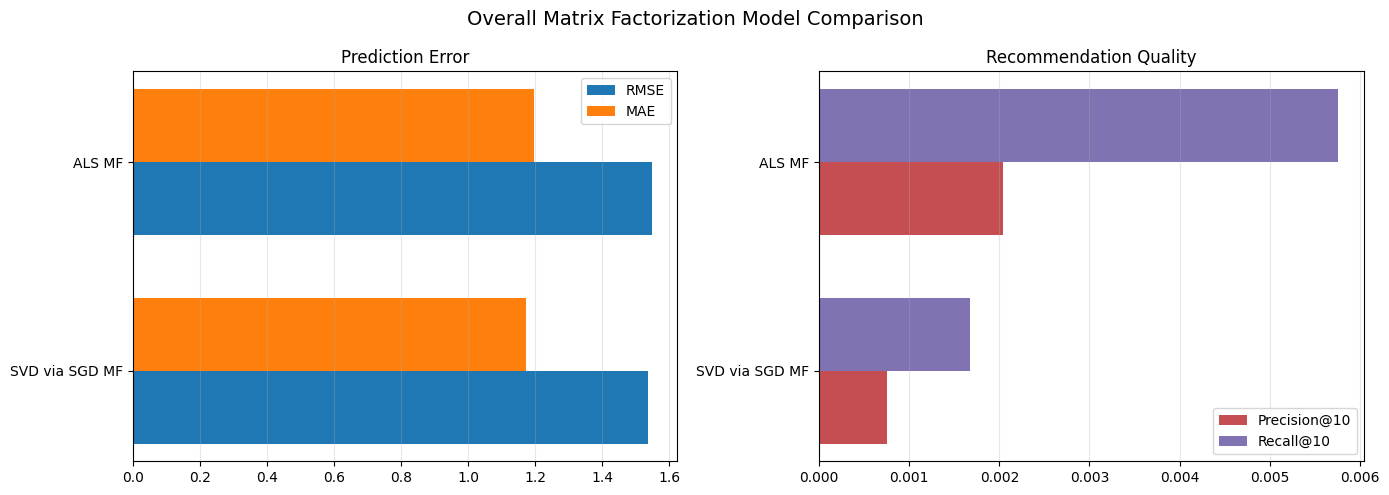

In [38]:
models = ["SVD via SGD MF", "ALS MF"]

rmse_scores = [svd_sgd_rmse, als_rmse]
mae_scores = [svd_sgd_mae, als_mae]

precision = [svd_sgd_precision, als_precision]
recall = [svd_sgd_recall, als_recall]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

y = np.arange(len(models))
h = 0.35

# Left: RMSE & MAE (Error Metrics)
axes[0].barh(y - h/2, rmse_scores, h, label="RMSE")
axes[0].barh(y + h/2, mae_scores, h, label="MAE")
axes[0].set_yticks(y)
axes[0].set_yticklabels(models)
axes[0].set_title("Prediction Error")
axes[0].grid(axis="x", alpha=0.3)
axes[0].legend()

# Right: Precision & Recall (Recommendatin Metrics)
axes[1].barh(y - h/2, precision, h, label="Precision@10", color="#C44E52")
axes[1].barh(y + h/2, recall, h, label="Recall@10", color="#8172B2")
axes[1].set_yticks(y)
axes[1].set_yticklabels(models)
axes[1].set_title("Recommendation Quality")
axes[1].grid(axis="x", alpha=0.3)
axes[1].legend()

plt.suptitle("Overall Matrix Factorization Model Comparison", fontsize=14)
plt.tight_layout()
plt.show()

Comparing the SVD via SGD and ALS models, the results showed different strengths depending on the evaluation metric. For rating prediction accuracy, both models achieved similar RMSE and MAE values, with SVD via SGD achieving slightly lower prediction errors. However, when evaluating top-K recommendation performance, ALS achieved higher Precision@10 and Recall@10 scores, suggesting that it was more effective at ranking relevant items for users.

Since this study evaluates both rating prediction accuracy and recommendation quality, both models were retained for further experimentation. SVD via SGD provides a strong baseline for explicit rating prediction, while ALS demonstrates competitive performance in ranking-based recommendation tasks. Keeping both models allows for a more complete comparison when incorporating additional user experience objectives, such as novelty and diversity.

The following experiments evaluate how the novelty-aware recommendation strategy affects each model and whether improving recommendation discovery introduces trade-offs in accuracy-based metrics.

# Part 5: Baseline Novelty and Diversity

## Novelty

In [39]:
# Create an overall novelty metric for the recommendation system
def novelty_at_k(
    test_data,
    train_data,
    prediction_function,
    model,
    k=10,
    novelty_weight=0.0
):
    
    # Store novelty values for all recommended books
    novelty_scores = []

     # Get the list of unique users we want to evaluate
    users = test_data["User-ID"].unique()
    
    # Count how many times each book appears in the training data
    # This is used as a measure of popularity
    book_popularity = train_data["ISBN"].value_counts()


    # Total number of user-book interactions
    total_interactions = len(train_data)

    # Calculate novelty for each user's recommendations
    for user_id in users:

        # Generate the top-k recommendations for the current user
        recommendations = get_top_k_recommendations(
            user_id=user_id,
            prediction_function=prediction_function,
            train=train_data,
            model=model,
            k_recommendations=k,
            novelty_weight=novelty_weight
        )

        # Calculate novelty score for each recommended book
        for book_id in recommendations:

            # Get the popularity of the book from the training data
            # If the book is unseen, assign a default popularity of 1   
            popularity = book_popularity.get(book_id, 1)

       # Calculate novelty using self-information
            novelty = -np.log2(
                popularity / total_interactions
            )
            
            novelty_scores.append(novelty)

    # Return 0 if no recommendations were generated
    if len(novelty_scores) == 0:
        return 0
    
    # Return the average novelty score across all recommendations
    return np.mean(novelty_scores)

In [40]:
svd_sgd_novelty_original = novelty_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_rating_svd_sgd,
    model=svd_sgd_model,
    k=10,
    novelty_weight=0.0
)

print(f"Novelty@10 SVD via SGD (original): {svd_sgd_novelty_original:.3f}")

Novelty@10 SVD via SGD (original): 12.717


In [41]:
als_novelty_original = novelty_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_rating_als,
    model=als_model,
    k=10,
    novelty_weight=0.0
)

print(f"Novelty@10 ALS (original): {als_novelty_original:.3f}")

Novelty@10 ALS (original): 11.445


## Diversity

In [42]:
# Create an overall diversity metric for the recommendation system
def diversity_at_k(
    test_data,
    train_data,
    books_data,
    prediction_function,
    model,
    k=10,
    novelty_weight=0.0
):
    
    # Store diversity values for all recommended books
    diversity_scores = []

     # Get the list of unique users we want to evaluate
    users = test_data["User-ID"].unique()

    # Calculate novelty for each user's recommendations
    for user_id in users:

        # Generate the top-k recommendations for the current user
        recommendations = get_top_k_recommendations(
            user_id=user_id,
            prediction_function=prediction_function,
            train=train_data,
            model=model,
            k_recommendations=k,
            novelty_weight=novelty_weight
        )

        if len(recommendations) == 0:
            continue

        # Get the authors of the recommended books
        recommended_authors = (
            books_data[
                books_data["ISBN"].isin(recommendations)
            ]["Author"]
            .dropna()
            .unique()
        )

        # Calculate diversity
        diversity = len(recommended_authors) / len(recommendations)

        diversity_scores.append(diversity)

    # Return 0 if no recommendations were generated
    if len(diversity_scores) == 0:
        return 0

    # Return the average novelty score across all recommendations
    return np.mean(diversity_scores)

In [43]:
svd_sgd_diversity_original = diversity_at_k(
    test_data=test,
    train_data=train,
    books_data=books,
    prediction_function=predict_rating_svd_sgd,
    model=svd_sgd_model,
    k=10,
    novelty_weight=0.0
)

print(f"Diversity@10 SVD via SGD (original): {svd_sgd_diversity_original:.3f}")

Diversity@10 SVD via SGD (original): 0.836


In [44]:
als_diversity_original = diversity_at_k(
    test_data=test,
    train_data=train,
    books_data=books,
    prediction_function=predict_rating_als,
    model=als_model,
    k=10,
    novelty_weight=0.0
)

print(f"Diversity@10 SVD via SGD (original): {als_diversity_original:.3f}")

Diversity@10 SVD via SGD (original): 0.816


# Part 6: Novelty-Aware Added


In [45]:
def get_top_k_recommendations(
        user_id,
        prediction_function,
        train,
        model,
        k_recommendations=10,
        candidate_size=3000,
        novelty_weight=0.1 
):
    
    # Books already rated by user
    rated_books = set(
        train.loc[
            train["User-ID"] == user_id,
            "ISBN"
        ]
    )

    # All available books
    all_books = train["ISBN"].unique()

    # Books the user has not rated
    unrated_books = [
        book_id
        for book_id in all_books
        if book_id not in rated_books
    ]

    # Randomly sample candidates if there are too many
    if len(unrated_books) > candidate_size:
        unrated_books = np.random.choice(
            unrated_books,
            size=candidate_size,
            replace=False
        )

    # Calculate popularity (number of ratings for each book)
    book_popularity = train["ISBN"].value_counts()
    
    predictions = {}

    for book_id in unrated_books:

        pred = prediction_function(
            user_id=user_id,
            book_id=book_id,
            model=model
        )

        if not np.isnan(pred):

            # More popular books receive a small penalty
            popularity = book_popularity.get(book_id, 1)

            adjusted_score = (
                pred - novelty_weight * np.log1p(popularity) # (log1p(x) is just a numerically stable way to compute log(1 + x))
            )

            predictions[book_id] = adjusted_score

    if len(predictions) == 0:
        return []
    
    return (
        pd.Series(predictions)
        .sort_values(ascending=False)
        .head(k_recommendations)
        .index
        .tolist()
    )

To support the user experience goal of increased novelty, the recommendation score was adjusted by penalizing highly popular books. Popularity was measured as the number of ratings each book received in the training data. The final ranking score was computed as:

adjusted_score = predicted_rating − novelty_weight × log(1 + popularity)

where predicted_rating is the rating predicted by the collaborative filtering model, novelty_weight controls the strength of the novelty adjustment, and popularity is the number of ratings the book has received. If a book's popularity is unavailable, a default value of 1 is used to ensure that the novelty score can always be computed and to prevent missing popularity information from causing errors during recommendation generation.

This approach encourages the recommender to surface relevant but less frequently rated books, increasing recommendation novelty while still prioritizing items that are predicted to match the user's preferences.

In [46]:
svd_sgd_precision_novad, svd_sgd_recall_novad = precision_recall_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_rating_svd_sgd,
    model=svd_sgd_model,
    k=10
)

print(f"Precision@10 SVD via SGD (novelty-aware): {svd_sgd_precision_novad:.3f}")
print(f"Recall@10 SVD via SGD (novelty-aware): {svd_sgd_recall_novad:.3f}")

Precision@10 SVD via SGD (novelty-aware): 0.000
Recall@10 SVD via SGD (novelty-aware): 0.001


In [47]:
als_precision_novad, als_recall_novad = precision_recall_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_rating_als,
    model=als_model,
    k=10
)

print(f"Precision@10 ALS (novelty-aware): {als_precision_novad:.3f}")
print(f"Recall@10 ALS (novelty-aware): {als_recall_novad:.3f}")

Precision@10 ALS (novelty-aware): 0.001
Recall@10 ALS (novelty-aware): 0.004


In [48]:
# Novelty with adjustment
svd_sgd_novelty_adjusted = novelty_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_rating_svd_sgd,
    model=svd_sgd_model,
    k=10,
    novelty_weight=0.1
)

print(f"Novelty@10 SVD via SGD (novelty-aware): {svd_sgd_novelty_adjusted:.3f}")

Novelty@10 SVD via SGD (novelty-aware): 13.050


In [49]:
als_novelty_adjusted = novelty_at_k(
    test_data=test,
    train_data=train,
    prediction_function=predict_rating_als,
    model=als_model,
    k=10,
    novelty_weight=0.1
)

print(f"Novelty@10 ALS (novelty-aware): {als_novelty_adjusted:.3f}")

Novelty@10 ALS (novelty-aware): 12.054


In [50]:
svd_sgd_diversity_after_novelty = diversity_at_k(
    test_data=test,
    train_data=train,
    books_data=books,
    prediction_function=predict_rating_svd_sgd,
    model=svd_sgd_model,
    k=10,
    novelty_weight=0.1
)

print(f"Diversity@10 SVD via SGD (novelty-aware): {svd_sgd_diversity_after_novelty:.3f}")

Diversity@10 SVD via SGD (novelty-aware): 0.864


In [51]:
als_diversity_after_novelty = diversity_at_k(
    test_data=test,
    train_data=train,
    books_data=books,
    prediction_function=predict_rating_als,
    model=als_model,
    k=10,
    novelty_weight=0.1
)

print(f"Diversity@10 ALS (novelty-aware): {als_diversity_after_novelty:.3f}")

Diversity@10 ALS (novelty-aware): 0.868


# Part 7: Computation Compilation

In [52]:
results = pd.DataFrame({
        "Precision@10 Original": [
            svd_sgd_precision,
            als_precision
        ],
        "Precision@10 Novelty-Aware": [
            svd_sgd_precision_novad,
            als_precision_novad
        ],
        "Recall@10 Original": [
            svd_sgd_recall,
            als_recall
        ],
        "Recall@10 Novelty-Aware": [
            svd_sgd_recall_novad,
            als_recall_novad
        ],
        "Novelty@10 Original":[
            svd_sgd_novelty_original,
            als_novelty_original
        ],

        "Novelty@10 Novelty-Aware":[
            svd_sgd_novelty_adjusted,
            als_novelty_adjusted
        ],
        "Diversity@10 Original":[
            svd_sgd_diversity_original,
            als_diversity_original
        ],
        "Diversity@10 Novelty-Aware":[
            svd_sgd_diversity_after_novelty,
            als_diversity_after_novelty
        ]
    },
    index=[
        "SVD via SGD",
        "ALS"
])

results

,Precision@10 Original,Precision@10 Novelty-Aware,Recall@10 Original,Recall@10 Novelty-Aware,Novelty@10 Original,Novelty@10 Novelty-Aware,Diversity@10 Original,Diversity@10 Novelty-Aware
SVD via SGD,0.000754,0.000429,0.001679,0.001023,12.717180,13.050153,0.836272,0.864297
ALS,0.002040,0.001388,0.005754,0.003662,11.444831,12.054366,0.815691,0.867508


The novelty-aware recommendation strategy improved both novelty and diversity for the SVD via SGD and ALS models. Novelty@10 increased from 12.717180 to 13.050153 for SVD via SGD and from 11.444831 to 12.054366 for ALS, indicating that the modified recommender system successfully introduced users to less frequently interacted books. This improvement was achieved by applying a popularity-based novelty adjustment that penalized highly popular books during reranking.

Similarly, Diversity@10 increased from 0.836272 to 0.864297 for SVD via SGD and from 0.815691 to 0.867508 for ALS, suggesting that the reranking strategy produced recommendation lists with a broader variety of authors.

These improvements were accompanied by a reduction in recommendation accuracy. For SVD via SGD, Precision@10 decreased from 0.000754 to 0.000429, while Recall@10 decreased from 0.001679 to 0.001023. For ALS, Precision@10 decreased from 0.002040 to 0.001388, and Recall@10 decreased from 0.005754 to 0.003662. This decrease is an expected consequence of the novelty-aware reranking strategy, which deliberately promotes less popular books instead of selecting only the highest-scoring recommendations. As a result, users are exposed to a wider range of items, but the recommendations are less likely to exactly match the interactions contained in the test set, leading to lower precision and recall. The results therefore demonstrate the fundamental trade-off in recommender systems between maximizing recommendation accuracy and encouraging exploration of less popular content.

The novelty and diversity improvements were consistent across both collaborative filtering approaches because the same novelty-aware reranking strategy was applied after candidate generation. Although both models experienced reductions in Precision@10 and Recall@10, ALS consistently maintained higher accuracy than SVD via SGD in both the baseline and novelty-aware settings. This suggests that ALS provides a better balance between recommendation relevance and the introduction of novel and diverse items, making it the stronger overall approach for this recommendation task.


In [57]:
def calculate_percentage_change(original, novelty_aware):
    return ((novelty_aware - original) / original) * 100


# SVD via SGD percentage changes
svd_precision_change = calculate_percentage_change(
    svd_sgd_precision,
    svd_sgd_precision_novad
)

svd_recall_change = calculate_percentage_change(
    svd_sgd_recall,
    svd_sgd_recall_novad
)

svd_novelty_change = calculate_percentage_change(
    svd_sgd_novelty_original,
    svd_sgd_novelty_adjusted
)

svd_diversity_change = calculate_percentage_change(
    svd_sgd_diversity_original,
    svd_sgd_diversity_after_novelty
)

# ALS percentage changes
als_precision_change = calculate_percentage_change(
    als_precision,
    als_precision_novad
)

als_recall_change = calculate_percentage_change(
    als_recall,
    als_recall_novad
)

als_novelty_change = calculate_percentage_change(
    als_novelty_original,
    als_novelty_adjusted
)

als_diversity_change = calculate_percentage_change(
    als_diversity_original,
    als_diversity_after_novelty
)


# Display results
print("Percentage Changes After Adding Novelty")
print("--------------------------------------")

print("SVD via SGD:")
print(f"Precision@10 change: {svd_precision_change:.2f}%")
print(f"Recall@10 change: {svd_recall_change:.2f}%")
print(f"Novelty@10 change: {svd_novelty_change:.2f}%")
print(f"Diversity@10 change: {svd_diversity_change:.2f}%")

print()

print("ALS:")
print(f"Precision@10 change: {als_precision_change:.2f}%")
print(f"Recall@10 change: {als_recall_change:.2f}%")
print(f"Novelty@10 change: {als_novelty_change:.2f}%")
print(f"Diversity@10 change: {als_diversity_change:.2f}%")

Percentage Changes After Adding Novelty
--------------------------------------
SVD via SGD:
Precision@10 change: -43.18%
Recall@10 change: -39.06%
Novelty@10 change: 2.62%
Diversity@10 change: 3.35%

ALS:
Precision@10 change: -31.93%
Recall@10 change: -36.36%
Novelty@10 change: 5.33%
Diversity@10 change: 6.35%


The novelty-aware approach produced consistent improvements in both novelty and diversity across the two collaborative filtering models. Compared with the baseline, Novelty@10 increased by 2.62% for SVD via SGD and 5.33% for ALS. Similarly, Diversity@10 improved by 3.35% for SVD via SGD and 6.35% for ALS. The larger improvements observed for ALS suggest that the novelty-aware reranking strategy had a stronger impact on expanding the range of recommended books while maintaining recommendation quality.

These improvements were accompanied by reductions in accuracy-based metrics. Precision@10 decreased by 43.18% for SVD via SGD and 31.93% for ALS, while Recall@10 decreased by 39.06% and 36.36%, respectively. The larger reduction in precision for SVD via SGD indicates that the reranking strategy had a greater impact on its ability to recommend highly relevant items, whereas ALS retained a larger proportion of its original accuracy. Overall, these findings demonstrate the expected trade-off between recommendation accuracy and recommendation novelty. By promoting less popular books, the novelty-aware approach increases users' opportunities for discovery and provides more diverse recommendation lists, but this comes at the cost of reduced precision and recall.


# Conclusion and Future Work

This study investigated collaborative filtering-based book recommendation using two matrix factorization approaches: SVD optimized with SGD and ALS. Both models were evaluated using rating prediction metrics (RMSE and MAE) and top-K recommendation metrics (Precision@10 and Recall@10). The results showed that SVD via SGD achieved slightly better rating prediction performance, while ALS demonstrated stronger ranking-based recommendation performance. These findings highlight that model effectiveness depends on the evaluation objective and the specific recommendation task being considered.

A novelty-aware reranking strategy was introduced to reduce the dominance of highly popular books and encourage the discovery of less frequently interacted items. The results demonstrated that this approach consistently improved both novelty and diversity for SVD via SGD and ALS, producing recommendation lists that exposed users to a broader range of books and authors. These improvements were accompanied by reductions in Precision@10 and Recall@10, highlighting the inherent trade-off between recommendation accuracy and exploration. By promoting less popular books, the novelty-aware approach reduced the likelihood of recommending only the highest-ranked relevant items identified by the baseline models. Although this resulted in lower accuracy according to traditional evaluation metrics, it increased the potential for users to discover books they might not otherwise encounter and reduced the influence of popularity bias. Among the two approaches, ALS maintained stronger recommendation accuracy after reranking while still achieving improvements in novelty and diversity, suggesting that it provided a better overall balance between recommendation relevance and recommendation discovery.

Although this study evaluated recommender system performance using offline metrics, future work could investigate the effectiveness of these approaches in an online evaluation environment involving real users. User engagement and satisfaction could be measured through metrics such as click-through rate, interaction time, saved books, explicit ratings, and qualitative feedback. Additionally, serendipity and catalog coverage could be evaluated to provide a more comprehensive assessment of recommendation quality. Serendipity would measure whether users discover recommendations that are both unexpected and relevant, while catalog coverage would assess whether the recommender system utilizes a broader range of available books. These aspects cannot be fully captured through historical rating data and traditional accuracy-based metrics alone.

A potential online evaluation framework would involve an A/B testing setup in which users are randomly assigned to either the baseline recommender or the novelty-aware recommender. User interactions could then be collected over a predefined period and statistically analyzed to determine whether the novelty-aware approach improves user experience while maintaining acceptable recommendation relevance.